# Exploratory Data Analysis of Road Accidents in the United Kingdom

### Motivations:

- Process the data to improve visualization and understanding
- Identify patterns in accident causes, locations, or vehicle types
- Explore and seek alternatives for possible accident prevention

Importing the modules

In [3]:
# Importing modules
import pandas as pd
import os
import geopandas as gpd
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns

# Importing modules from src package
from src.preprocessing import *
from src.plotting import *

# Style of the charts
plt.style.use("dark_background")

Importing and cleaning data

In [4]:
# Storing the file path in a variable
PATH = r"input\Road Accident Data.csv"

# Loading the dataset
df = pd.read_csv(PATH)

# Removing the "Accident_Index" column as it is not necessary for analysis
df = df.drop("Accident_Index", axis=1)

# Displaying the DataFrame
df

,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,1/1/2021,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,1/5/2021,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,1/4/2021,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,1/5/2021,Jan,Monday,2021,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,1/6/2021,Jan,Tuesday,2021,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307968,2/18/2022,Feb,Thursday,2022,Data missing or out of range,Not at junction or within 20 metres,Slight,57.374005,Daylight,Highland,...,2,1,Northern,Dry,Single carriageway,60,7:00,Rural,Fine no high winds,Car
307969,2/21/2022,Feb,Sunday,2022,Data missing or out of range,Not at junction or within 20 metres,Slight,57.232273,Darkness - no lighting,Highland,...,1,1,Northern,Frost or ice,Single carriageway,60,3:00,Rural,Fine no high winds,Car
307970,2/23/2022,Feb,Tuesday,2022,Give way or uncontrolled,T or staggered junction,Slight,57.585044,Daylight,Highland,...,1,3,Northern,Frost or ice,Single carriageway,30,9:38,Rural,Fine no high winds,Car
307971,2/23/2022,Feb,Tuesday,2022,Give way or uncontrolled,T or staggered junction,Serious,57.214898,Darkness - no lighting,Highland,...,1,2,Northern,Wet or damp,Single carriageway,60,18:25,Rural,Fine no high winds,Motorcycle over 500cc


Converting to the correct data types

In [5]:
# Converting the Accident Date column do datetime
df["Accident Date"] = pd.to_datetime(df["Accident Date"])

# Defining categorical columns
categorical_cols = [
    "Month", "Day_of_Week", "Junction_Control", "Junction_Detail", 
    "Accident_Severity", "Light_Conditions", "Local_Authority_(District)",
    "Police_Force", "Road_Surface_Conditions", 
    "Road_Type", "Urban_or_Rural_Area", "Weather_Conditions", "Vehicle_Type"
]

# Applying the function to convert categorical columns
df = convert_to_category(df, categorical_cols)

# Displaying column data types
print(df.dtypes)

Accident Date                 datetime64[ns]
Month                               category
Day_of_Week                         category
Year                                   int64
Junction_Control                    category
Junction_Detail                     category
Accident_Severity                   category
Latitude                             float64
Light_Conditions                    category
Local_Authority_(District)          category
Carriageway_Hazards                   object
Longitude                            float64
Number_of_Casualties                   int64
Number_of_Vehicles                     int64
Police_Force                        category
Road_Surface_Conditions             category
Road_Type                           category
Speed_limit                            int64
Time                                  object
Urban_or_Rural_Area                 category
Weather_Conditions                  category
Vehicle_Type                        category
dtype: obj

Checking for and handling missing values

In [6]:
# Defining columns to be dropped due to excessive missing values
columns_to_remove = ["Carriageway_Hazards", "Time"]

# Dropping the columns in the list
df.drop(columns=columns_to_remove, inplace=True)

# Dropping any remaining rows with missing values
df.dropna(inplace=True)

# Checking the sum of the NA values
df.isna().sum()

Accident Date                 0
Month                         0
Day_of_Week                   0
Year                          0
Junction_Control              0
Junction_Detail               0
Accident_Severity             0
Latitude                      0
Light_Conditions              0
Local_Authority_(District)    0
Longitude                     0
Number_of_Casualties          0
Number_of_Vehicles            0
Police_Force                  0
Road_Surface_Conditions       0
Road_Type                     0
Speed_limit                   0
Urban_or_Rural_Area           0
Weather_Conditions            0
Vehicle_Type                  0
dtype: int64

Checking for unique values in each column

In [7]:
# Defining columns to exclude from the unique values check
columns_to_skip = ["Accident Date",
                   "Month",
                   "Day_of_Week",
                   "Latitude",
                   "Longitude"
                ]

# Checking for unique values in the dataset, excluding the specified columns
display_unique_values(df, columns_to_skip)


Unique Values per Column:
Year: 2 unique values.
Junction_Control: 6 unique values.
Junction_Detail: 9 unique values.
Accident_Severity: 3 unique values.
Light_Conditions: 5 unique values.
Local_Authority_(District): 422 unique values.
Number_of_Casualties: 28 unique values.
Number_of_Vehicles: 17 unique values.
Police_Force: 51 unique values.
Road_Surface_Conditions: 5 unique values.
Road_Type: 5 unique values.
Speed_limit: 8 unique values.
Urban_or_Rural_Area: 2 unique values.
Weather_Conditions: 8 unique values.
Vehicle_Type: 15 unique values.


Analysing the quantity of each type of accident severity (Slight, Serious, or Fatal)

In [8]:
# Generating a Pandas Series where the index is the unique values (Slight, Serious, and Fatal) 
# and the values are the count of each unique value
severity_counts = generate_severity_counts(df)

# Displaying the values in a more user-friendly percentage format
display_severity_counts(severity_counts)

Slight: 85.37 %
Serious: 13.34 %
Fatal: 1.30 %


Generating a barplot with the 3 types of accident severities

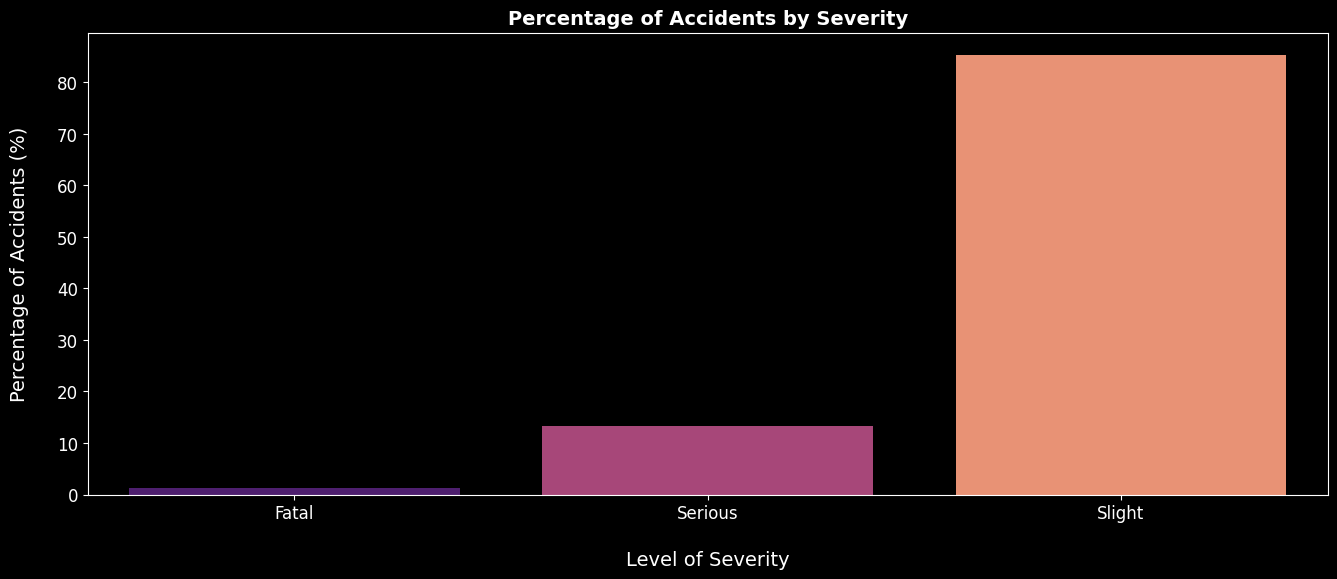

In [9]:
plot_severities_distribution(severity_counts, save_img=True)

DataFrame with only the Accident Severity column

In [10]:
# Creating the severity DataFrame
df_severity = df[["Accident_Severity"]]

# Showing the first 10 values
df_severity.head(10)

,Accident_Severity
0,Serious
1,Serious
2,Slight
3,Serious
4,Serious
5,Slight
6,Serious
7,Slight
8,Slight
9,Slight


Creating a DataFrame with only severe accidents (serious or fatal)

In [11]:
# Creating the new DataFrame with serious and fatal accidents
df_severe = df[df["Accident_Severity"].isin(["Serious", "Fatal"])]

# Putting the count of the values in a Pd Series
series_severe_accidents = df_severe["Accident_Severity"].value_counts()

# Filtering to ensure that just serious and fatal accidents are going to be in the series
series_severe_accidents = series_severe_accidents[series_severe_accidents.index.isin(["Serious", "Fatal"])]

# Showing the count
series_severe_accidents

Accident_Severity
Serious    40086
Fatal       3892
Name: count, dtype: int64

Grouping by Month for Serious and Fatal Accidents

In [12]:
# List with the months in the correct order
ordered_months = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

# Grouping by month and reindexing using the list with the ordered months
series_monthly = df_severe.groupby("Month").size().reindex(ordered_months)
series_monthly

C:\Users\berna\AppData\Local\Temp\ipykernel_7908\845100914.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  series_monthly = df_severe.groupby("Month").size().reindex(ordered_months)


Month
Jan    3113
Feb    2997
Mar    3660
Apr    3719
May    4045
Jun    4003
Jul    3920
Aug    3817
Sep    4072
Oct    4006
Nov    3750
Dec    2876
dtype: int64

Plotting the number of severe accidents grouping by month

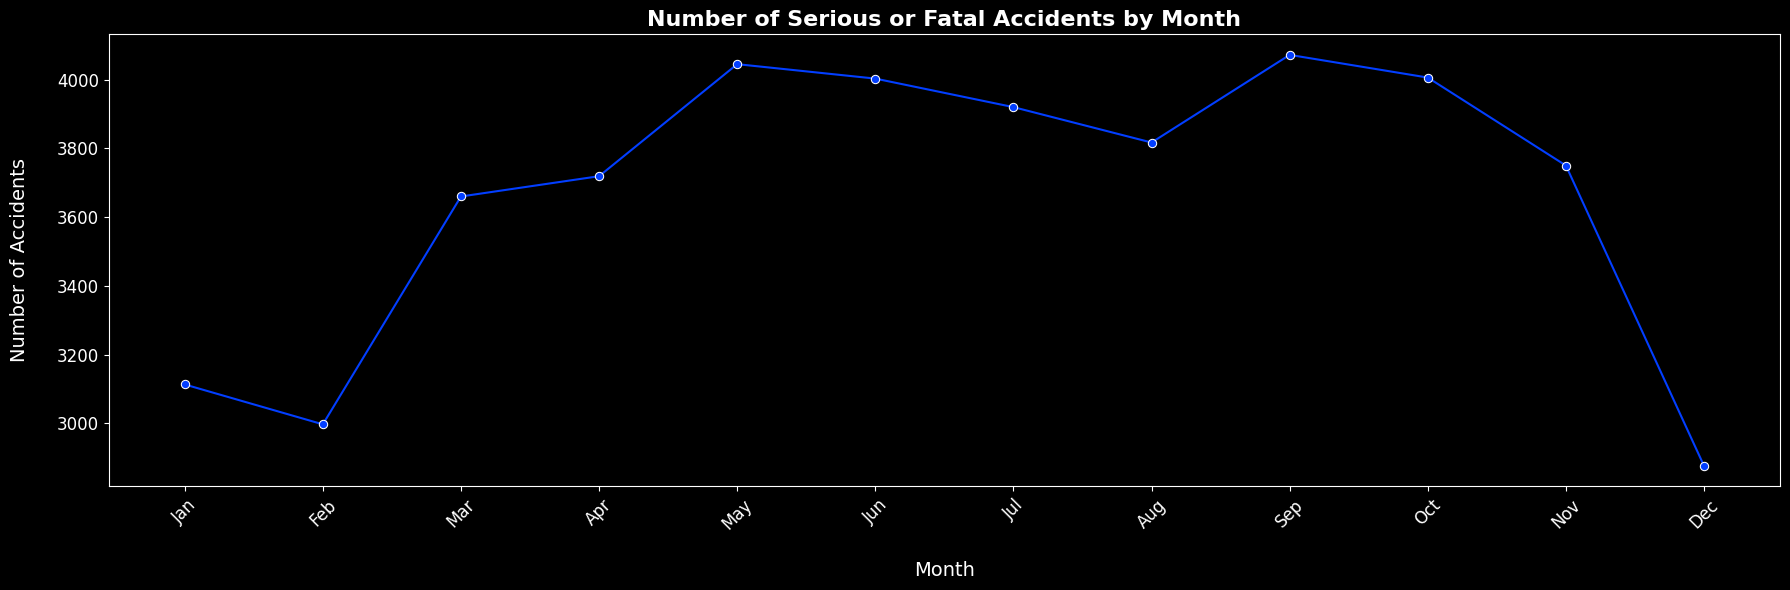

In [13]:
plot_accidents_by_month(series_monthly, save_img=True)

Separating and visualizing the serious and fatal accidents per vehicle type

In [14]:
# Generating a series with the vehicle types and the counts
vehicle_types = df_severe["Vehicle_Type"].value_counts()
# Setting a numeric index for the dataframe
vehicle_types = vehicle_types.reset_index()

# Filtering the dataframe to keep only rows where the number of occurrences
#  is greater than 400, ignoring vehicles with fewer appearances
vehicle_types_filtered = vehicle_types[vehicle_types["count"] > 300]
# Sorting the dataframe in ascending order to make a chart that gradually
#  increases, like a staircase
vehicle_types_filtered = vehicle_types_filtered.sort_values(by="count",
                                                             ascending=True)

# Creating lists to save the data of each column and use them as the axis 
# data source

#  List with the numbers of the vehicle type counts
list_of_counts = [count_ for count_ in vehicle_types_filtered["count"]]

# List with the names of the vehicles in the vehicle type column
list_of_labels = [vehicle for vehicle in vehicle_types_filtered["Vehicle_Type"]]

vehicle_types_filtered

,Vehicle_Type,count
10,Goods over 3.5t. and under 7.5t,375
9,Other vehicle,378
8,Motorcycle over 125cc and up to 500cc,458
7,Motorcycle 50cc and under,539
6,Taxi/Private hire car,784
5,Goods 7.5 tonnes mgw and over,921
4,Motorcycle 125cc and under,991
3,Bus or coach (17 or more pass seats),1205
2,Motorcycle over 500cc,1611
1,Van / Goods 3.5 tonnes mgw or under,2292


Plotting a bar chart of the vehicle types in accidents

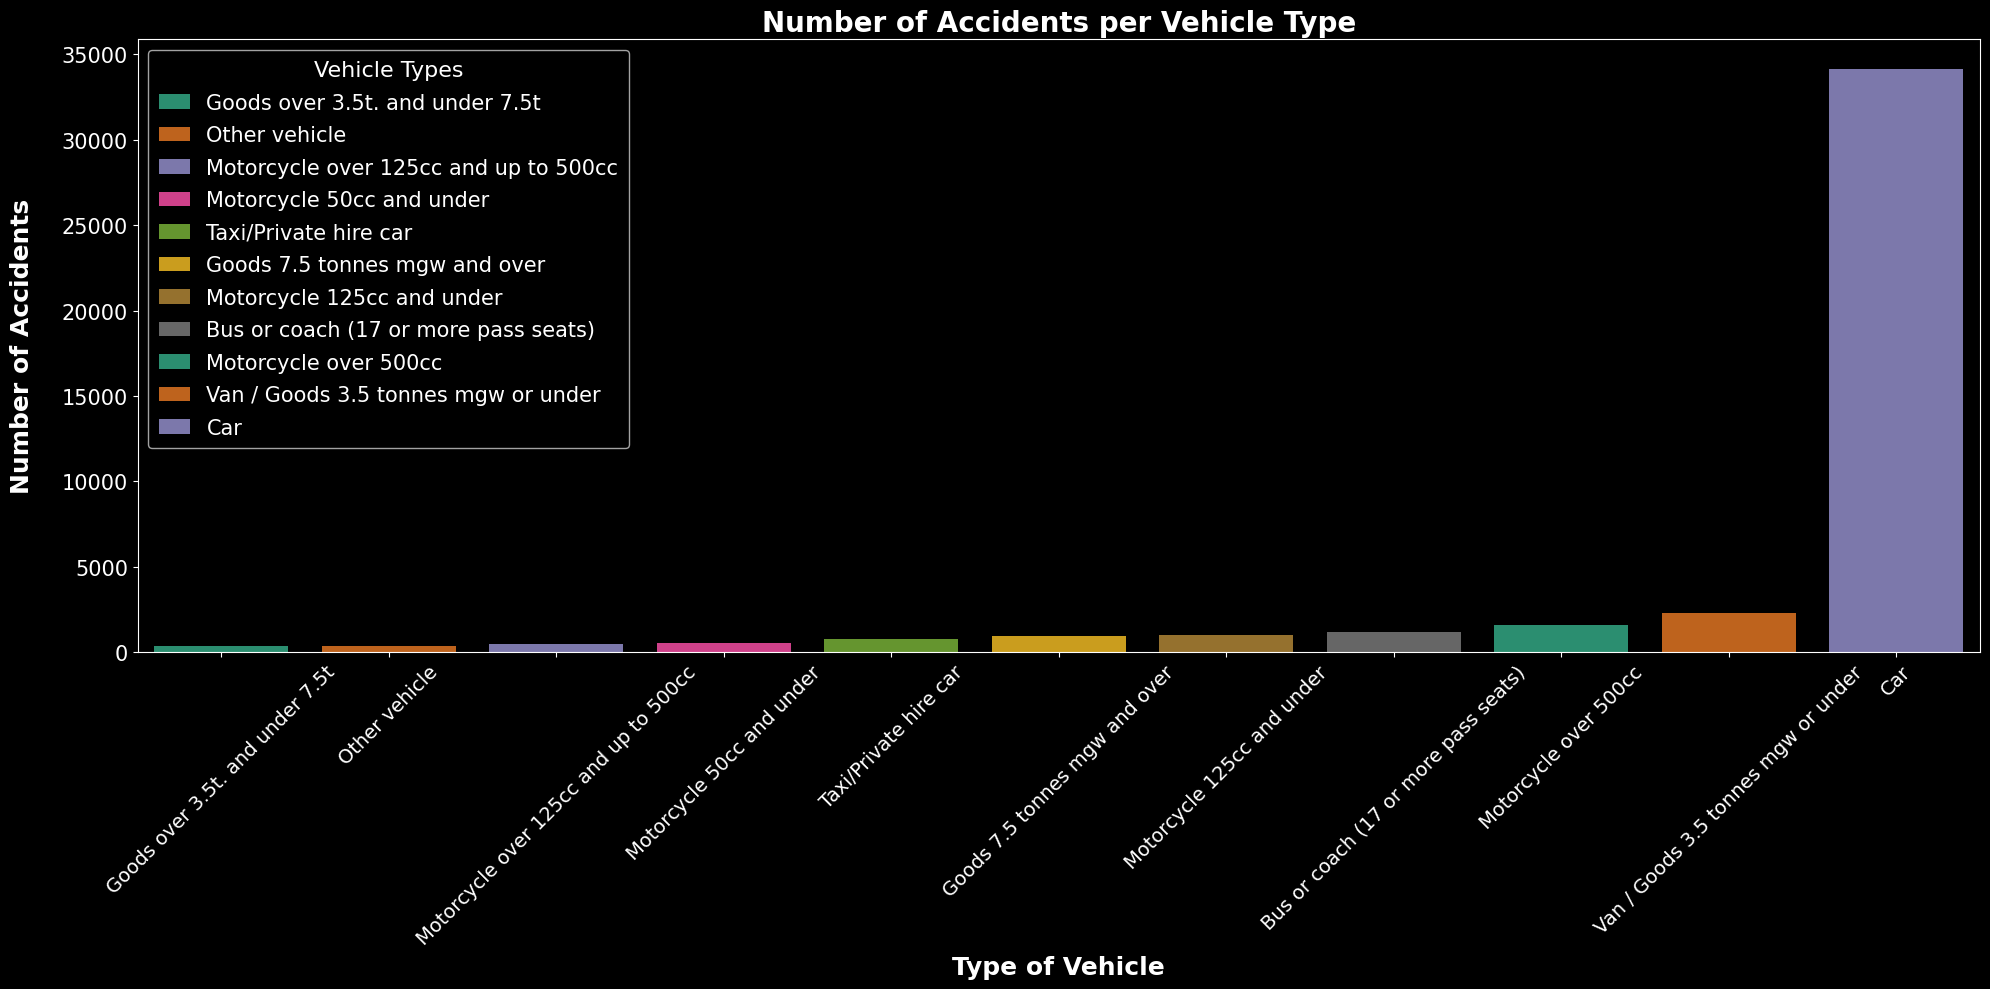

In [15]:
plot_vehicle_types(list_of_counts, list_of_labels, vehicle_types_filtered, save_img=True)

Creating a Series with the data of weather, lightning and road surface conditions and showing the Data

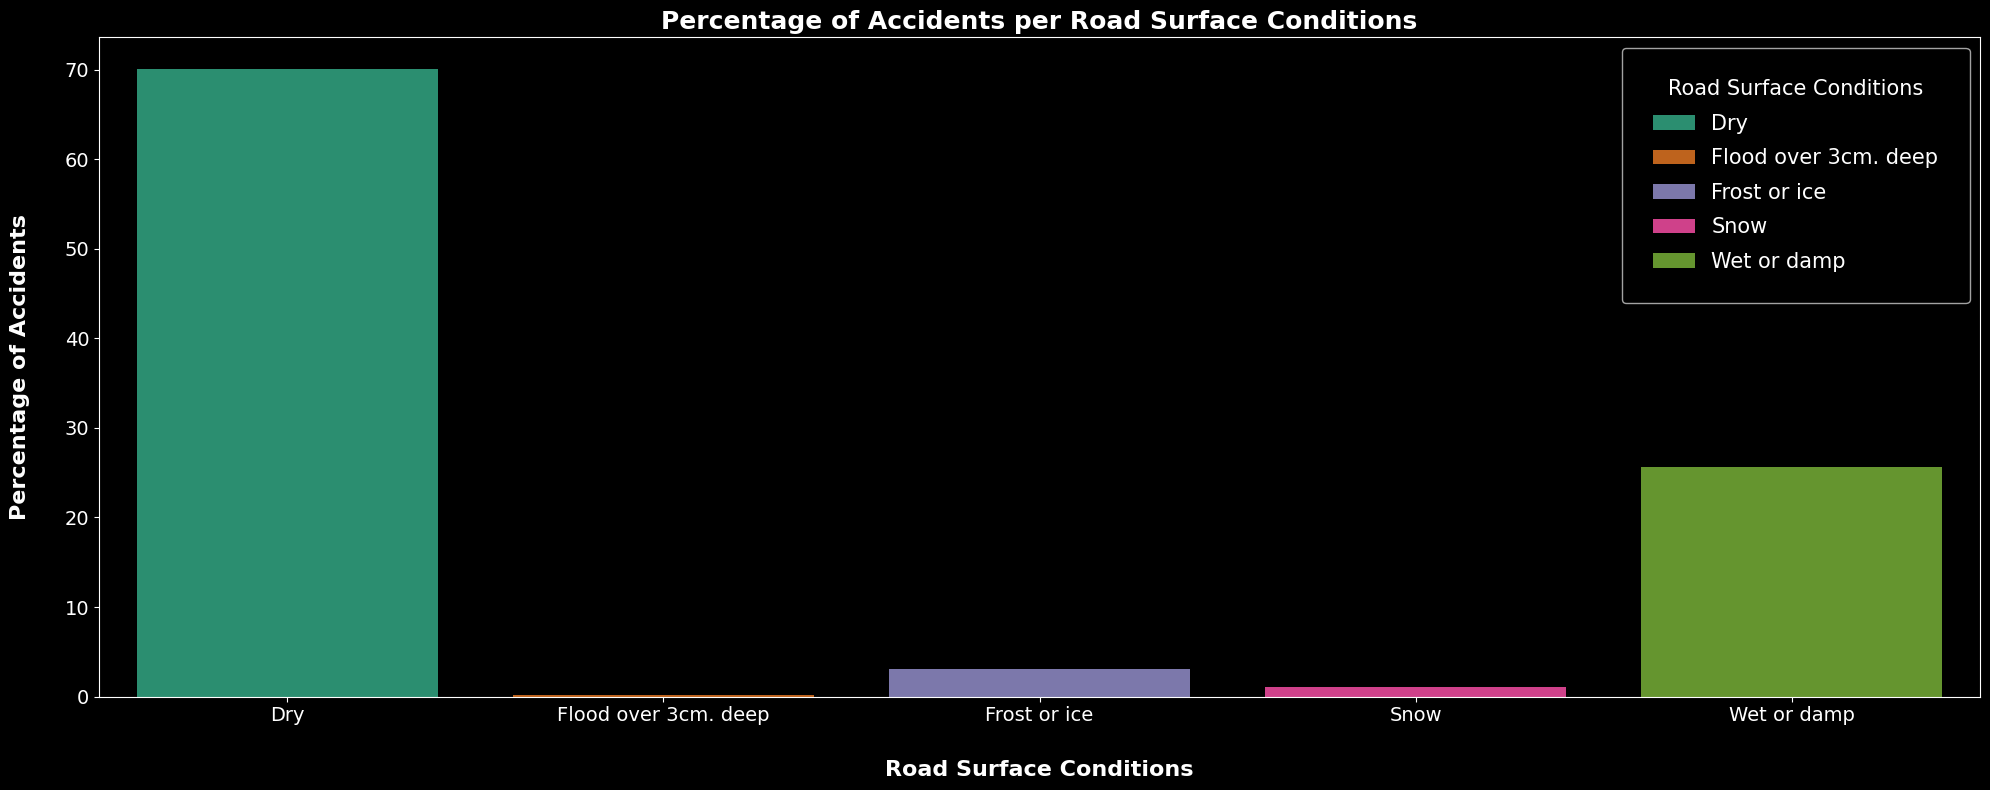

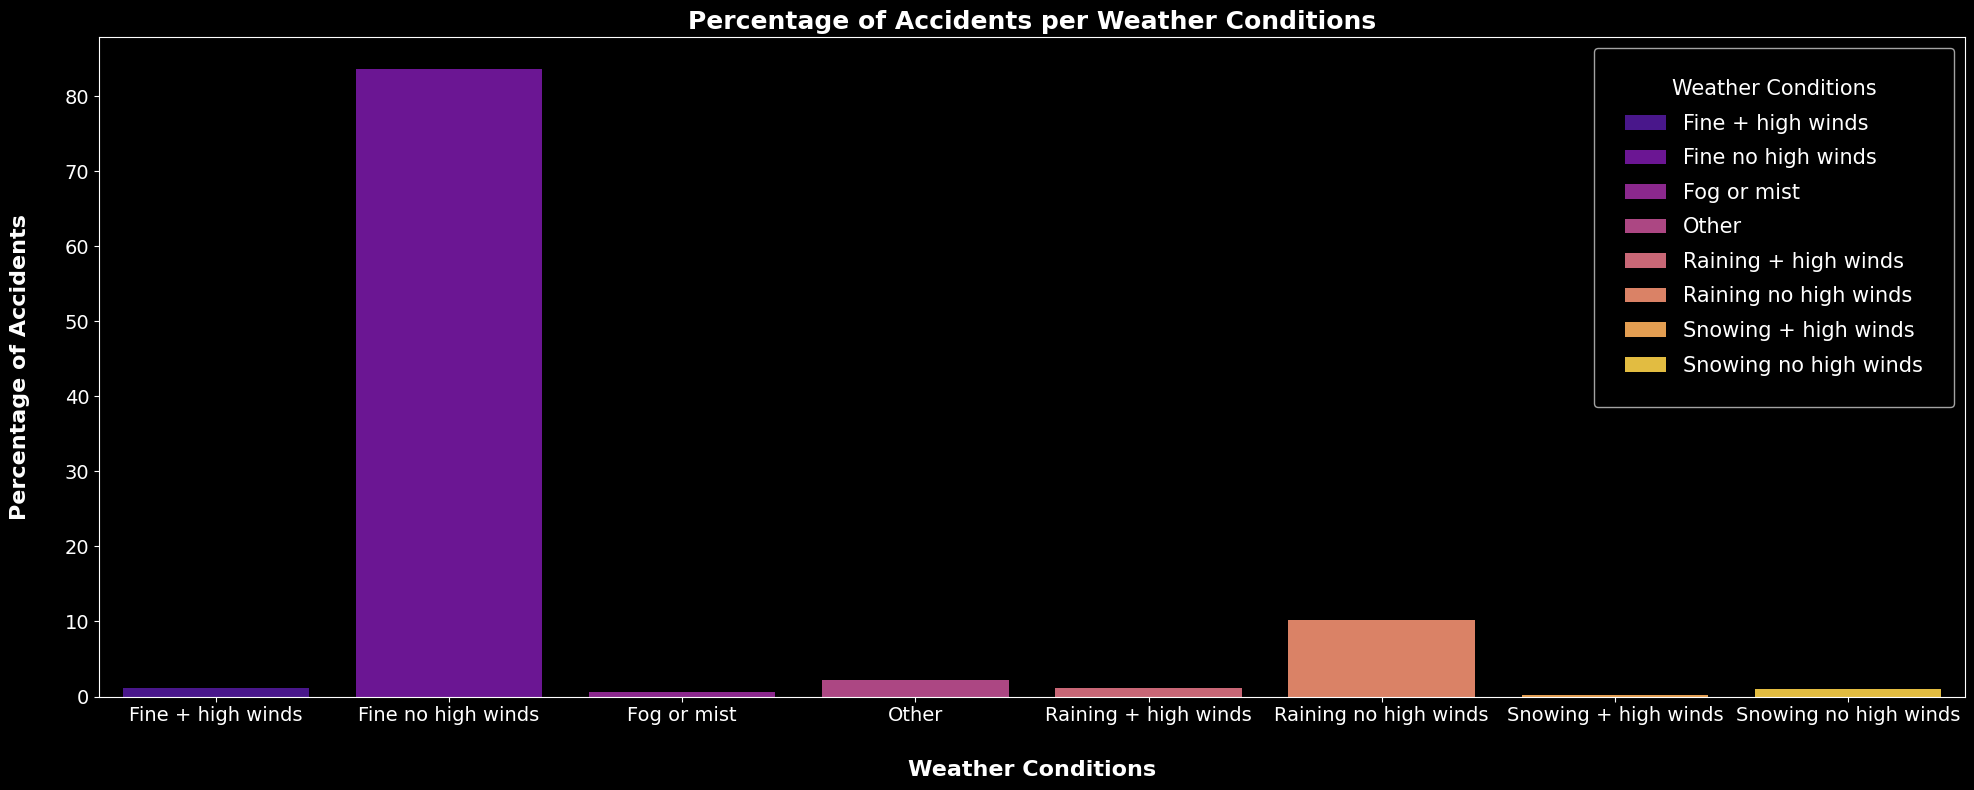

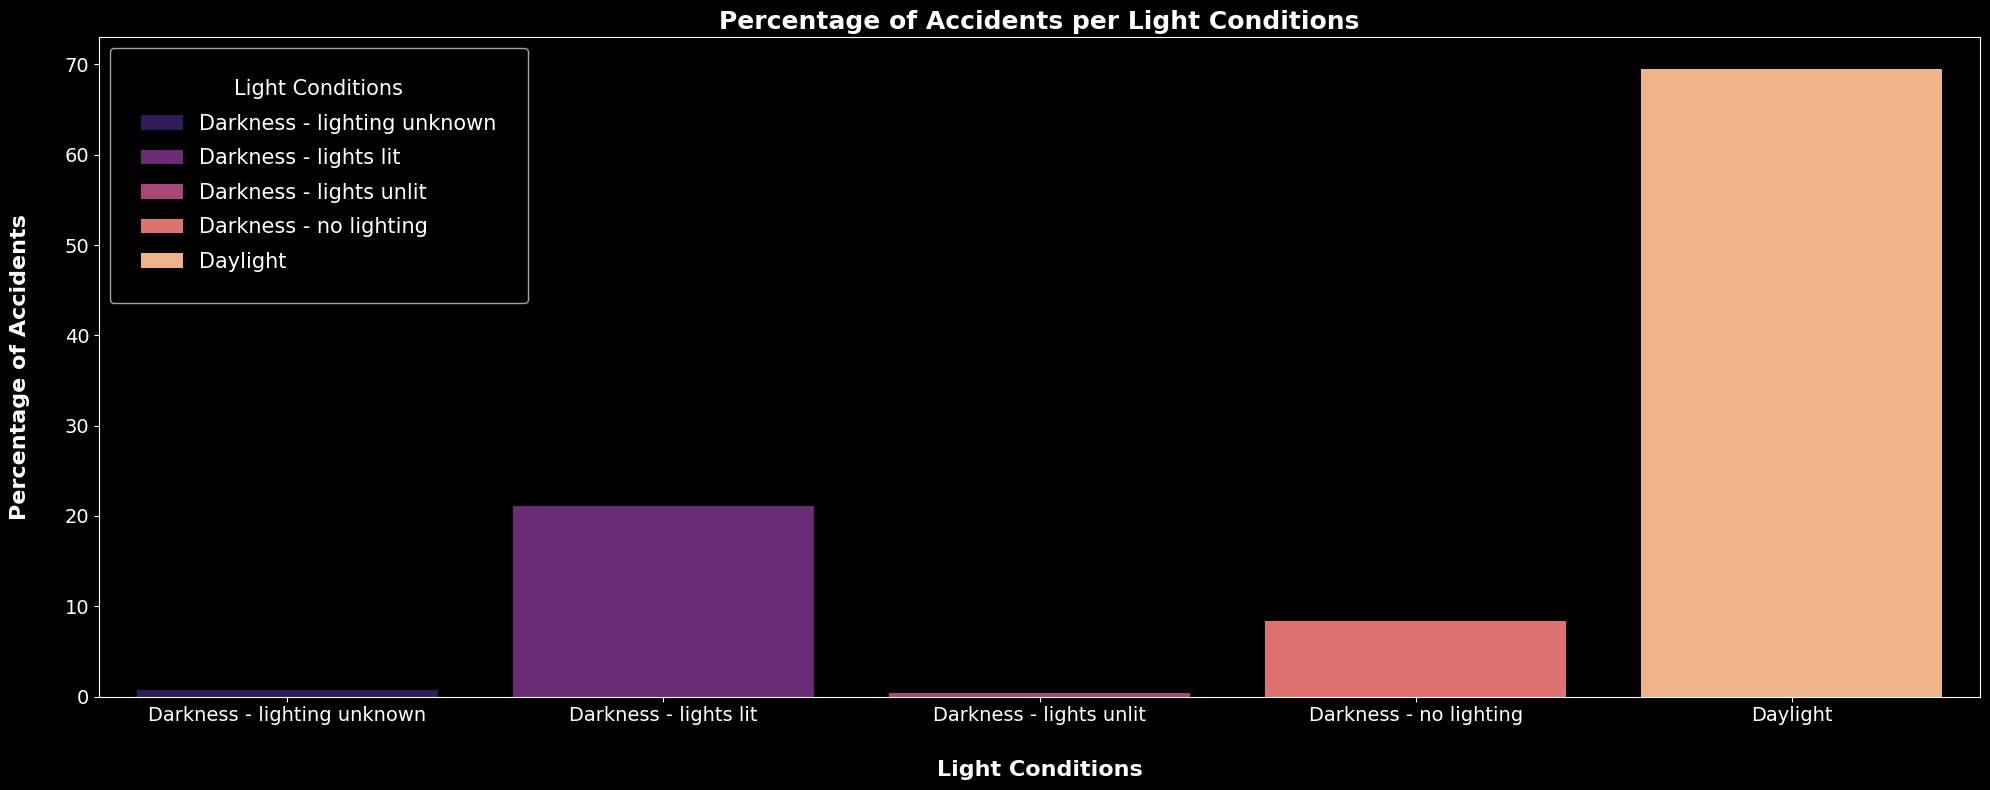

In [16]:
# Creating a DataFrame with the road surface conditions
df_other_conditions = df_severe[
    ["Road_Surface_Conditions", "Weather_Conditions", "Light_Conditions"]
]

# Plotting the road surface conditions
plot_other_conditions(df_other_conditions)

Removing the "data missing or out of range" values from the Junction Control column

In [17]:
# Filter out rows where the "Junction_Control" column has the value
#  "Data missing or out of range"
df_severe = df_severe[df_severe["Junction_Control"] != "Data missing or out of range"]

# Remove unused categories from the "Junction_Control" column to ensure that
# any categories marked as "Data missing or out of range" are excluded
df_severe["Junction_Control"] = df_severe["Junction_Control"].cat.remove_unused_categories()
df_severe["Junction_Control"].value_counts()

Junction_Control
Give way or uncontrolled               19170
Not at junction or within 20 metres     4431
Auto traffic signal                     3545
Stop sign                                185
Authorised person                         43
Name: count, dtype: int64

Creating a Series with the quantity of accidents per Junction Control type

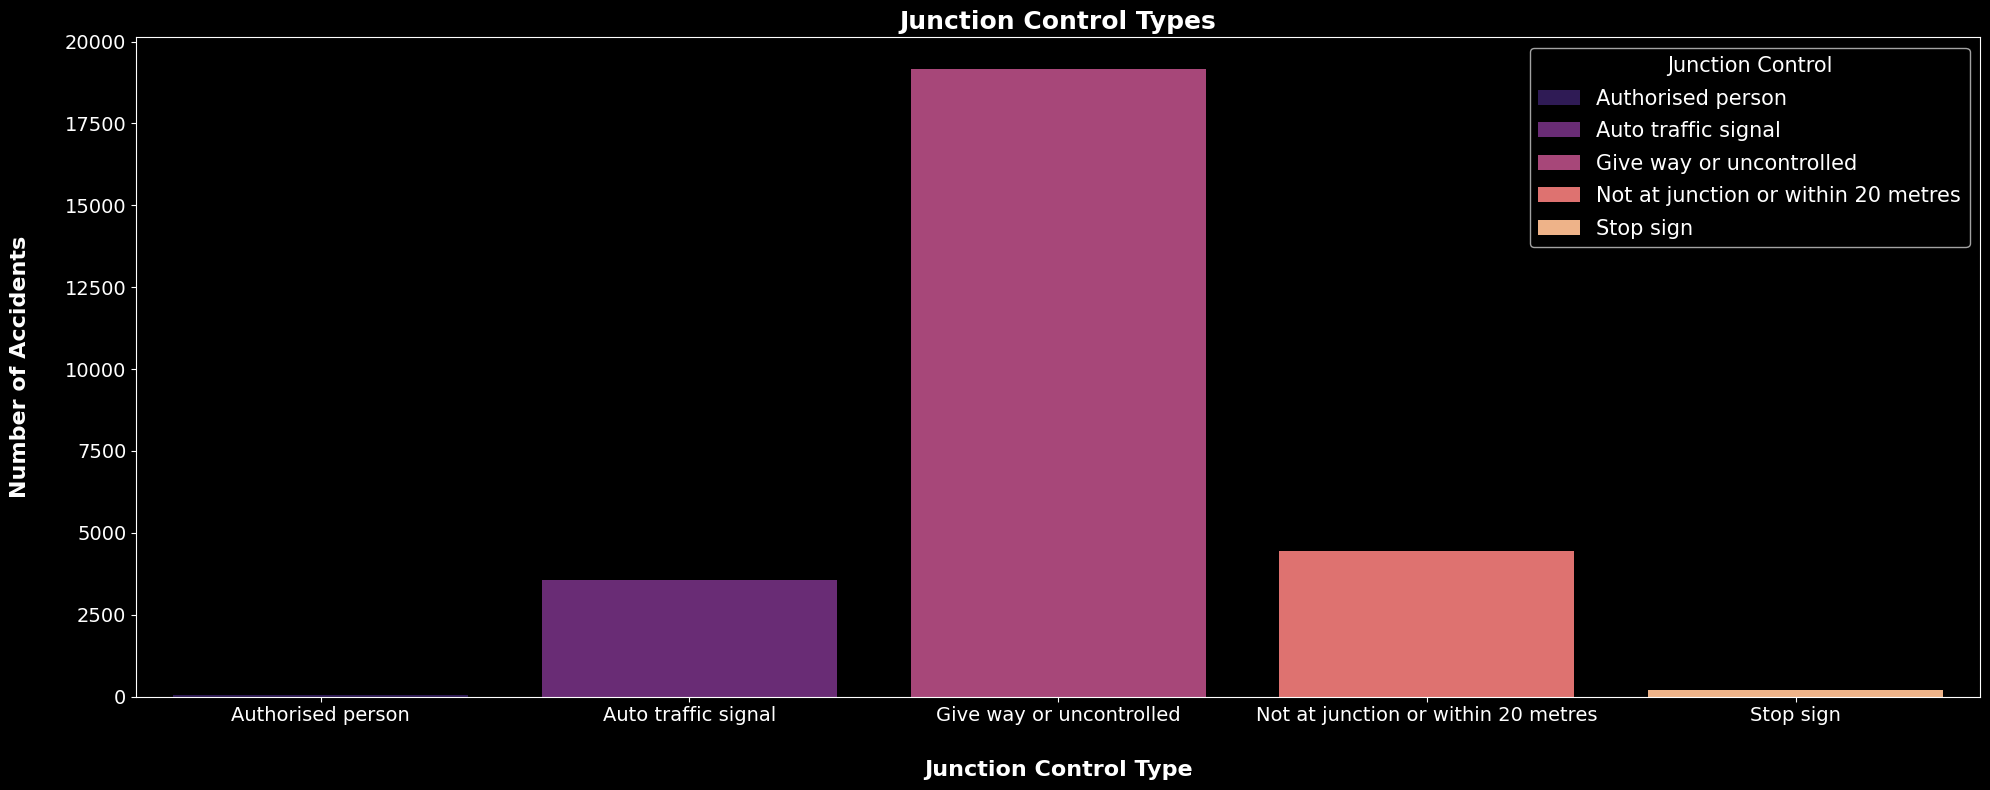

In [18]:
plot_junction_control(df_severe, save_img=True)

Building a GeoDataFrame with geometrys data

In [19]:
# Creating geometry of points of accidents
geometrys = gpd.points_from_xy(df["Longitude"], df["Latitude"])

# Building the GeoDataFrame
geo_df = gpd.GeoDataFrame(df, geometry=geometrys)
geo_df

,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,geometry
0,2021-01-01,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,...,1,2,Metropolitan Police,Dry,One way street,30,Urban,Fine no high winds,Car,POINT (-0.20135 51.51227)
1,2021-01-05,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,Urban,Fine no high winds,Taxi/Private hire car,POINT (-0.19925 51.5144)
2,2021-01-04,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,...,1,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Taxi/Private hire car,POINT (-0.1796 51.48667)
3,2021-01-05,Jan,Monday,2021,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,Urban,Other,Motorcycle over 500cc,POINT (-0.20311 51.5078)
4,2021-01-06,Jan,Tuesday,2021,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,...,1,2,Metropolitan Police,Dry,Single carriageway,30,Urban,Fine no high winds,Car,POINT (-0.17344 51.48208)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307968,2022-02-18,Feb,Thursday,2022,Data missing or out of range,Not at junction or within 20 metres,Slight,57.374005,Daylight,Highland,...,2,1,Northern,Dry,Single carriageway,60,Rural,Fine no high winds,Car,POINT (-3.46783 57.374)
307969,2022-02-21,Feb,Sunday,2022,Data missing or out of range,Not at junction or within 20 metres,Slight,57.232273,Darkness - no lighting,Highland,...,1,1,Northern,Frost or ice,Single carriageway,60,Rural,Fine no high winds,Car,POINT (-3.80928 57.23227)
307970,2022-02-23,Feb,Tuesday,2022,Give way or uncontrolled,T or staggered junction,Slight,57.585044,Daylight,Highland,...,1,3,Northern,Frost or ice,Single carriageway,30,Rural,Fine no high winds,Car,POINT (-3.86273 57.58504)
307971,2022-02-23,Feb,Tuesday,2022,Give way or uncontrolled,T or staggered junction,Serious,57.214898,Darkness - no lighting,Highland,...,1,2,Northern,Wet or damp,Single carriageway,60,Rural,Fine no high winds,Motorcycle over 500cc,POINT (-3.824 57.2149)


Creating a HeatMap with the accidents ocurrence

In [20]:
# Creating the map with Folium
accidents_map = folium.Map(
    location=[df["Latitude"].mean(), df["Longitude"].mean()], zoom_start=5
)

# Creating a list with the accident points from the GeoDataFrame, using list comprehension
heatmap_data = [[point.xy[1][0], point.xy[0][0]] for point in geo_df["geometry"]]

# Creating the heatmap to visualize the accidents ocurrence
folium.plugins.HeatMap(
    heatmap_data, name="Accidents on UK Roads", radius=11, blur=15, max_zoom=10
).add_to(accidents_map)

# Saving the heatmap as an HTML file to provide an alternative way to view the map.
# This is necessary because interactive maps generated with Folium do not render directly on GitHub.
# By saving the map as an HTML file, users can open it in any web browser without needing to execute the notebook.
accidents_map.save("heatmap.html")

# Visualizing the map
accidents_map

# Analysis of Extracted Data and Potential Solutions

- The number of serious and fatal accidents does not appear to be correlated with weather, road surface conditions, or lighting.

- Analyzing the distribution of serious and fatal accidents reveals a noticeable seasonal trend. From December to February, the frequency of severe accidents tends to decrease, while September marks the peak month, with over four thousand accidents recorded.

- Reviewing the Junction Types chart reveals two key observations. Firstly, junctions with a stop sign or an authorized traffic controller are associated with fewer than a thousand accidents, suggesting that these control measures effectively reduce accident likelihood. In contrast, junctions with give-way signs or no control see a significantly higher number of severe accidents. This suggests that improving junction control measures could significantly enhance road safety.

## Further Examination of Other Conditions Yields the Following Insights:

### Weather, Light, and Road Surface Conditions Don't Appear to Be the Main Causes of Accidents
In the majority of accidents, road conditions were good, as were the lighting and weather. This may indicate reckless driving or driver imprudence. It is also possible that when conditions worsen, fewer people venture onto the roads. Notably, accident numbers drop during the last three months of the year and in January. Since the UK experiences colder weather during this period, this aspect will be explored in greater detail in future analyses.

### Light Conditions
Lighting conditions do not seem to be a decisive factor in road safety. Fewer than 10% of accidents occur under poor lighting, while nearly 70% take place during daylight hours.

### Weather Conditions
More than 80% of accidents happen under favorable weather conditions. Adverse conditions such as snow, rain, and fog contribute to only a small percentage of accidents.

### Road Surface Conditions
Similar to weather and lighting conditions, most accidents occur on dry road surfaces. However, over 20% of accidents take place on wet or icy roads, suggesting that road surface conditions still play a significant role in accident frequency.

### Junction Control
Junction control appears to be one of the most critical factors in accident rates. Locations with an authorized traffic controller, a stop sign, or any form of strict control experience significantly fewer accidents.

### Capitals and Large Cities
As expected, the number of accidents is higher in large cities and capitals, likely due to higher traffic density and congestion.

### Driver Error
The data suggests that driver error, combined with insufficient junction control, is a major contributing factor to accidents. The presence of stronger junction control correlates with a lower number of accidents.

### Vehicle Types
The Vehicle Types chart highlights a significant disparity in accident data. Nearly 35,000 accidents involve cars, while all other vehicle types combined account for fewer than 5,000 incidents. According to the Society of Motor Manufacturers and Traders (SMMT), 1,613,922 cars were sold in the UK in 2022, compared to only 108,065 motorcycles. This imbalance in vehicle sales likely contributes to the high number of car-related accidents. Nonetheless, there is a need for new traffic regulations and initiatives aimed at reducing car accidents and improving overall road safety.

### Impact of Winter on Accident Reduction
Another possible reason for the decline in accidents between December and February is the winter season in the UK. Cold temperatures, ice, and snowfall may lead to fewer vehicles on the road, as people opt for alternative transportation or avoid driving altogether. This could contribute to the observed seasonal decline in accidents.

**These findings suggest that some of the primary causes of accidents may include insufficient junction control, reckless driving, and wet or icy road conditions.**